# Validation Framework — Telecom Customer Churn

This notebook establishes the validation methodology for comparing
classification models and selecting decision thresholds.

Objectives:

- Keep the final test set untouched during model development
- Use stratified 5-fold cross-validation on the training data
- Generate out-of-fold churn probabilities
- Evaluate PR-AUC and ROC-AUC on out-of-fold predictions
- Establish the foundation for validation-based threshold selection

The final test set will be reserved for the final evaluation of models and
decision thresholds.

In [21]:
from pathlib import Path
import sys

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preprocessing import (
    build_preprocessor,
    load_raw_data,
    prepare_dataset,
)
from src.data.split import create_train_test_split
from src.modeling.validation import (
    create_stratified_cv,
    evaluate_probabilities,
    generate_oof_predictions,
)

In [13]:
df = load_raw_data()

X, y = prepare_dataset(df)

X_train, X_test, y_train, y_test = create_train_test_split(
    X,
    y,
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (6762, 9)
Test set: (1691, 9)


In [14]:
validation_model = Pipeline(
    steps=[
        ('Preprocessor', build_preprocessor(scale_numeric=True)),
        ('Classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

validation_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [15]:
cv = create_stratified_cv(n_splits=5, random_state=42)

oof_proba = generate_oof_predictions(model=validation_model, X=X_train, y=y_train, cv=cv)

print("OOF predictions:", oof_proba.shape)
print("Minimum probability:", oof_proba.min())
print("Maximum probability:", oof_proba.max())

OOF predictions: (6762,)
Minimum probability: 2.2038205373206476e-05
Maximum probability: 0.3009574911673459


In [16]:
oof_metrics = evaluate_probabilities(
    y_train,
    oof_proba,
)

oof_metrics

PR-AUC     0.082645
ROC-AUC    0.567171
dtype: float64

## Validation-Based Threshold Analysis

The model produces probabilities rather than final business decisions.

A classification threshold converts those probabilities into a binary
churn decision.

Because the churn class is highly imbalanced, the default threshold of 0.50
is not assumed to be appropriate.

Thresholds are evaluated using out-of-fold predictions from the training set.
The final test set is not used for threshold selection.

In [17]:
from src.modeling.thresholds import evaluate_thresholds

In [18]:
thresholds = [
    0.02,
    0.03,
    0.04,
    0.05,
    0.06,
    0.07,
    0.08,
    0.09,
    0.10,
    0.12,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
]

threshold_results = evaluate_thresholds(
    y_true=y_train,
    y_proba=oof_proba,
    thresholds=thresholds,
)

threshold_results

,Threshold,Customers Flagged,Coverage,Precision,Recall,F1
0,0.02,6740,0.996747,0.064985,0.997722,0.122023
1,0.03,6718,0.993493,0.065049,0.995444,0.122118
2,0.04,6625,0.979740,0.064906,0.979499,0.121744
3,0.05,5263,0.778320,0.069732,0.835991,0.128727
4,0.06,3189,0.471606,0.078081,0.567198,0.137266
5,0.07,2092,0.309376,0.082218,0.391800,0.135915
6,0.08,1325,0.195948,0.090566,0.273349,0.136054
7,0.09,803,0.118752,0.095890,0.175399,0.123994
8,0.10,474,0.070098,0.113924,0.123007,0.118291
9,0.12,142,0.021000,0.091549,0.029613,0.044750


In [19]:
threshold_results.sort_values(
    "F1",
    ascending=False,
).reset_index(drop=True)

,Threshold,Customers Flagged,Coverage,Precision,Recall,F1
0,0.06,3189,0.471606,0.078081,0.567198,0.137266
1,0.08,1325,0.195948,0.090566,0.273349,0.136054
2,0.07,2092,0.309376,0.082218,0.391800,0.135915
3,0.05,5263,0.778320,0.069732,0.835991,0.128727
4,0.09,803,0.118752,0.095890,0.175399,0.123994
5,0.03,6718,0.993493,0.065049,0.995444,0.122118
6,0.02,6740,0.996747,0.064985,0.997722,0.122023
7,0.04,6625,0.979740,0.064906,0.979499,0.121744
8,0.10,474,0.070098,0.113924,0.123007,0.118291
9,0.12,142,0.021000,0.091549,0.029613,0.044750


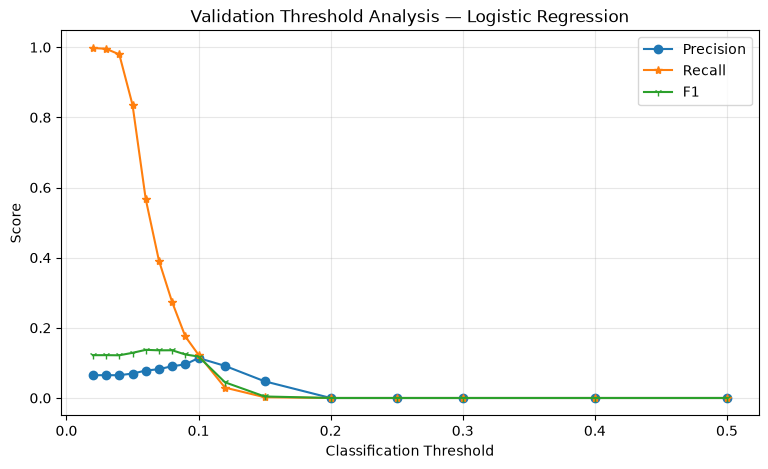

In [23]:
plt.figure(figsize=(9,5))

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Recall'],
    marker='*',
    label='Recall'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['F1'],
    marker='1',
    label='F1'
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Analysis — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Threshold Analysis — Validation Findings

Threshold selection was performed exclusively on out-of-fold predictions
from the training set. The final test set was not used.

The baseline Logistic Regression produces useful ranking signal, but its
default 0.50 classification threshold is inappropriate for this imbalanced
churn problem and results in zero predicted churners.

Across the evaluated validation thresholds, 0.06 produced the highest F1
score (0.1373). At this threshold:

- Customers flagged: 3,189
- Coverage: 47.16%
- Precision: 7.81%
- Recall: 56.72%
- F1: 0.1373

However, this threshold is treated as a validation diagnostic rather than
a final production decision. The appropriate operating threshold should
eventually be determined from the business objective, intervention capacity,
and cost of false positives versus false negatives.

The final test set remains untouched for unbiased evaluation.